In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df_interval = pd.read_csv('./data/D - Interval.csv', index_col=0)
df_interval.head(10)

,Month,Day,Interval,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,April,1,00:00:00,1.0,30.0,0.0,0.0,306.00
1,April,1,00:30:00,1.0,29.0,0.0,0.0,353.14
2,April,1,01:00:00,1.0,25.0,0.0,0.0,373.76
3,April,1,01:30:00,1.0,9.0,0.0,0.0,364.44
4,April,1,02:00:00,1.0,4.0,0.0,0.0,276.25
5,April,1,02:30:00,1.0,9.0,0.0,0.0,300.78
6,April,1,03:00:00,1.0,3.0,0.0,0.0,218.33
7,April,1,03:30:00,NaN,0.0,0.0,NaN,NaN
8,April,1,04:00:00,NaN,0.0,0.0,NaN,NaN
9,April,1,04:30:00,NaN,0.0,0.0,NaN,NaN


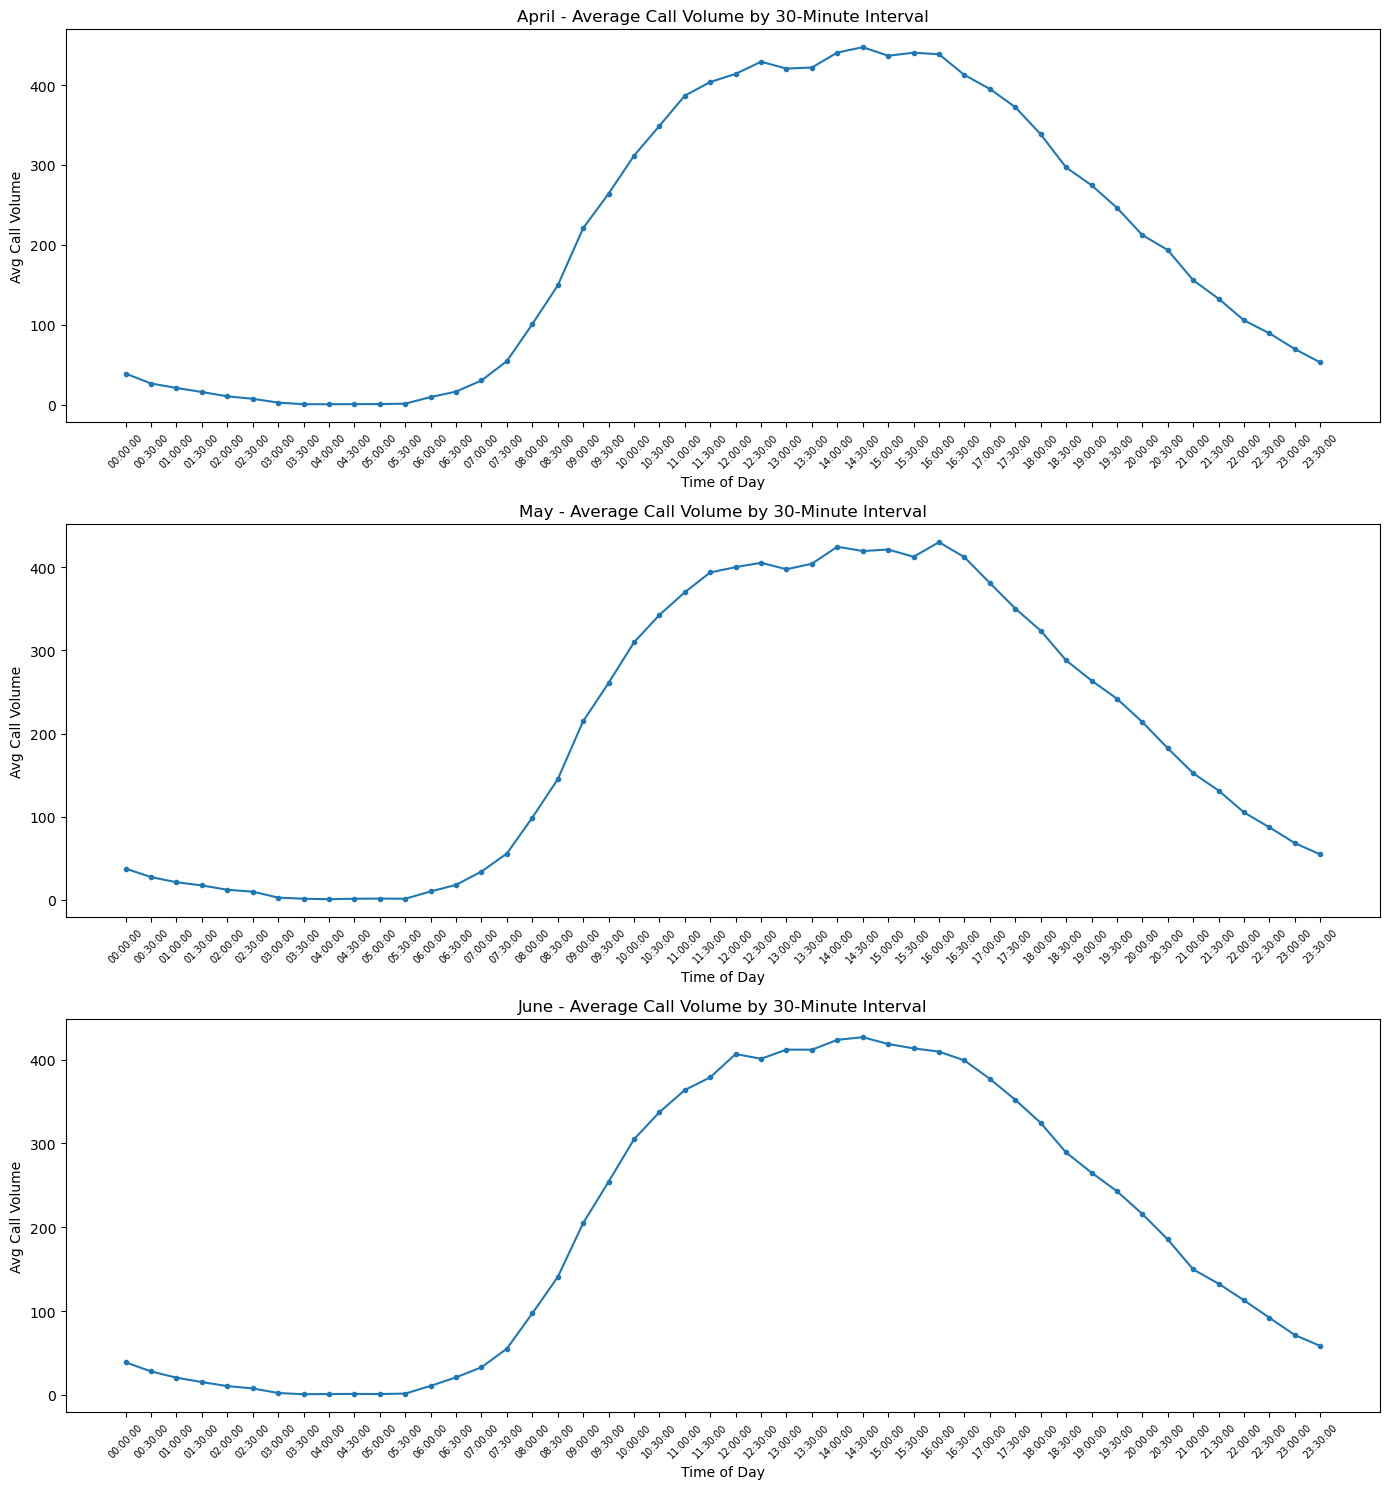

In [5]:
months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_interval[df_interval['Month'] == month]
    interval_volume = df_month.groupby('Interval')['Call Volume'].mean().reset_index()
    
    ax.plot(interval_volume['Interval'], interval_volume['Call Volume'], marker='o', linewidth=1.5, markersize=3)
    ax.set_title(f'{month} - Average Call Volume by 30-Minute Interval')
    ax.set_xlabel('Time of Day')
    ax.set_ylabel('Avg Call Volume')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df_interval = pd.read_csv('./data/D - Interval.csv', index_col=0)


# 1. Define the start and end of the period
# April 1st, 2025 at 00:00 to June 30th, 2025 at 23:30
start = '2025-04-01 00:00:00'
end = '2025-06-30 23:30:00'

# 2. Generate the date range with 30-minute frequency
# 30min or 30T is the frequency for 30-minute increments
dr = pd.date_range(start=start, end=end, freq='30min')

# 3. Create the DataFrame and extract the requested columns
df = pd.DataFrame({'Timestamp': dr})

df_intervals = pd.DataFrame({
    'Month': df['Timestamp'].dt.month_name(),
    'Day': df['Timestamp'].dt.day,
    'Interval': df['Timestamp'].dt.strftime('%H:%M:%S'),
    'Day of the Week': df['Timestamp'].dt.day_name()
})

df = df_intervals.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')
df['Call Volume'] = df['Call Volume'].interpolate(method='polynomial', order=2).astype(int)
df['Service Level'] = df['Service Level'].interpolate(method='polynomial', order=1)
df['Abandoned Rate'] = df['Abandoned Rate'].interpolate(method='linear')
df['CCT'] = df['CCT'].interpolate(method='polynomial', order=2)
mask = df['Abandoned Calls'].isna()
df.loc[mask, 'Abandoned Calls'] = (df.loc[mask, 'Abandoned Rate'] * df.loc[mask, 'Call Volume']).astype(int)

In [3]:
df.head(40)

,Month,Day,Interval,Day of the Week,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,April,1,00:00:00,Tuesday,1.0000,30,0.0,0.0000,306.000000
1,April,1,00:30:00,Tuesday,1.0000,29,0.0,0.0000,353.140000
2,April,1,01:00:00,Tuesday,1.0000,25,0.0,0.0000,373.760000
3,April,1,01:30:00,Tuesday,1.0000,9,0.0,0.0000,364.440000
4,April,1,02:00:00,Tuesday,1.0000,4,0.0,0.0000,276.250000
5,April,1,02:30:00,Tuesday,1.0000,9,0.0,0.0000,300.780000
6,April,1,03:00:00,Tuesday,1.0000,3,0.0,0.0000,218.330000
7,April,1,03:30:00,Tuesday,1.0000,0,0.0,0.0000,153.113393
8,April,1,04:00:00,Tuesday,1.0000,0,0.0,0.0000,133.918683
9,April,1,04:30:00,Tuesday,1.0000,0,0.0,0.0000,145.347132
